In [ ]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib widget


{'Source': -0.6770833333333334, 'CL1': -0.4895833333333333, 'CL2': -0.4479166666666667, 'CLMini': -0.09583333333333333, 'Objective lens Pre': -0.010416666666666666, 'Sample': 0.0, 'Objective lens Post': 0.0020833333333333333, 'SAAperture': 0.18958333333333333, 'IL1': 0.20208333333333334, 'IL2': 0.2791666666666667, 'IL3': 0.3416666666666667, 'PL1': 0.39375, 'Screen': 0.71875}


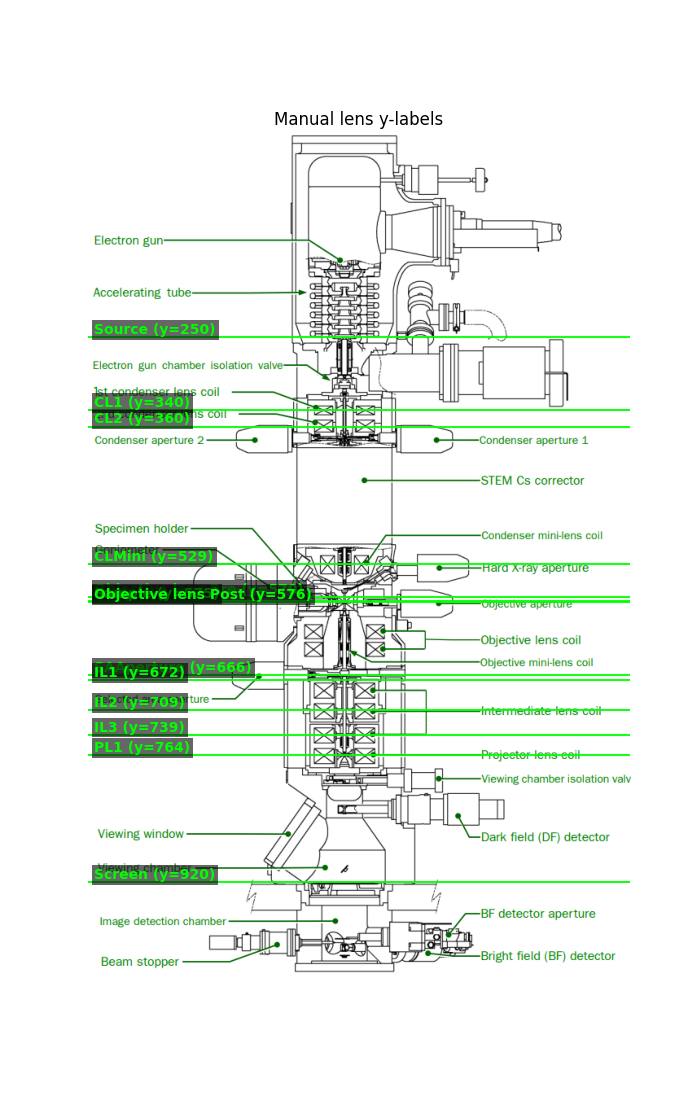

Distances between lenses (in meters): [0.1875     0.04166667 0.35208333 0.08541667 0.01041667 0.00208333
 0.1875     0.0125     0.07708333 0.0625     0.05208333 0.325     ]
CAD priors [mm]:
  d_object_to_opl: 2.083
  d_opl_to_saa: 187.500
  d_opl_to_il1: 200.000
  d_il1_to_il2: 77.083
  d_il2_to_il3: 62.500
  d_il3_to_pl1: 52.083
  d_pl1_to_det: 325.000


In [10]:
# Manually fill y-pixel positions for each lens label.
# Leave as None until you set a value.
label_y = {
    "Source": 250,
    "CL1": 340,
    "CL2": 360,
    "CLMini": 529,
    "Objective lens Pre": 570,
    "Sample": 575,
    "Objective lens Post": 576,
    'SAAperture': 666,
    "IL1": 672,
    "IL2": 709,
    "IL3": 739,
    "PL1": 764,
    "Screen": 920,
}

length_scale_px = 624 - 528
length_scale_m = 0.2  # 20 cm - length of elliptical box on left hand side of image.
px_to_m = length_scale_m / length_scale_px

label_y_m = {k: (v - 575) * px_to_m if v is not None else None for k, v in label_y.items()}
print(label_y_m)

img = plt.imread('microscope.png')
# Plot image with horizontal label lines at each filled y value
fig, ax = plt.subplots(figsize=(7, 11))
ax.imshow(img, origin="upper")

for name, y in label_y.items():
    if y is None:
        continue
    y = int(y)
    ax.axhline(y, color="lime", lw=1.5, alpha=0.9)
    ax.text(
        8, y - 4, f"{name} (y={y})",
        color="lime", fontsize=10, fontweight="bold",
        bbox=dict(facecolor="black", alpha=0.6, edgecolor="none", pad=2),
    )

ax.set_title("Manual lens y-labels")
ax.axis("off")
plt.show()

# Optional cleaned dict (only filled labels)
lens_z = {k: int(v) for k, v in label_y.items() if v is not None}
lens_z

y_vals_m = np.array([v for v in label_y_m.values() if v is not None], dtype=float)
distances = np.diff(y_vals_m - np.min(y_vals_m))
print("Distances between lenses (in meters):", distances)


def _abs_delta_m(a: str, b: str) -> float:
    va = label_y_m.get(a, None)
    vb = label_y_m.get(b, None)
    if va is None or vb is None:
        raise ValueError(f"Missing y-label(s) for '{a}' or '{b}'.")
    return float(abs(vb - va))

CAD_PRIOR_POS_M = {
    'Source': label_y_m['Source'],
    'CL1': label_y_m['CL1'],
    'CL2': label_y_m['CL2'],
    'CLMini': label_y_m['CLMini'],
    'Objective lens Pre': label_y_m['Objective lens Pre'],
    'Sample': label_y_m['Sample'],
    'Objective lens Post': label_y_m['Objective lens Post'],
    'SAAperture': label_y_m['SAAperture'],
    'IL1': label_y_m['IL1'],
    'IL2': label_y_m['IL2'],
    'IL3': label_y_m['IL3'],
    'PL1': label_y_m['PL1'],
    'Screen': label_y_m['Screen'],
}

# CAD-derived geometric priors used by projector fit (source/objective/post-obj onwards).
CAD_PRIOR_DISTS_M = {
    'd_object_to_opl': _abs_delta_m('Sample', 'Objective lens Post'),
    'd_opl_to_saa': _abs_delta_m('Objective lens Post', 'SAAperture'),
    'd_opl_to_il1': _abs_delta_m('Objective lens Post', 'IL1'),
    'd_il1_to_il2': _abs_delta_m('IL1', 'IL2'),
    'd_il2_to_il3': _abs_delta_m('IL2', 'IL3'),
    'd_il3_to_pl1': _abs_delta_m('IL3', 'PL1'),
    'd_pl1_to_det': _abs_delta_m('PL1', 'Screen'),
}

print('CAD priors [mm]:')
for k, v in CAD_PRIOR_DISTS_M.items():
    print(f"  {k}: {1e3 * v:.3f}")

